In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [30]:
# caminho do arquivo
data_path = "./Aula003-Pontos-Extendido.csv"

# coluna alvo
target_col = "class"

# colunas de entrada
feature_cols = ["x", "y"]

# parâmetros do modelo
test_size = 0.2
random_state = 42
k = 3
metric = "euclidean"      # pode trocar para "manhattan"
weights = "distance"      # "uniform" ou "distance"
scaler_type = "minmax"    # "minmax" ou "standard"

# ponto novo para prever
new_point = {
    "x": 420,
    "y": 800
}

In [31]:
df = pd.read_csv(data_path)

print("Shape:", df.shape)
print("\nColunas:")
print(df.columns.tolist())

print("\nPrimeiras linhas:")
display(df.head())

Shape: (131, 3)

Colunas:
['x', 'y', 'class']

Primeiras linhas:


,x,y,class
0,170,504,blue
1,555,640,blue
2,610,850,blue
3,126,598,blue
4,140,270,blue


In [32]:
df = df[feature_cols + [target_col]].copy()
df = df.dropna(subset=[target_col]).drop_duplicates()

X = df[feature_cols].copy()
y = df[target_col].copy()

numeric_cols = X.select_dtypes(include=["number"]).columns.tolist()
categorical_cols = [col for col in X.columns if col not in numeric_cols]

print("Colunas numéricas:", numeric_cols)
print("Colunas categóricas:", categorical_cols)
print("Classes:")
print(y.value_counts())

Colunas numéricas: ['x', 'y']
Colunas categóricas: []
Classes:
class
red     107
blue     24
Name: count, dtype: int64


In [33]:
if scaler_type == "minmax":
    scaler = MinMaxScaler()
elif scaler_type == "standard":
    scaler = StandardScaler()
else:
    raise ValueError("scaler_type deve ser 'minmax' ou 'standard'")

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", scaler)
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_cols),
        ("cat", categorical_transformer, categorical_cols)
    ]
)

In [34]:
stratify_y = y if y.nunique() > 1 else None

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=test_size,
    random_state=random_state,
    stratify=stratify_y
)

print("Treino:", X_train.shape)
print("Teste:", X_test.shape)

Treino: (104, 2)
Teste: (27, 2)


In [35]:
model = Pipeline(steps=[
    ("prep", preprocessor),
    ("knn", KNeighborsClassifier(
        n_neighbors=k,
        metric=metric,
        weights=weights
    ))
])

model.fit(X_train, y_train)

Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   MinMaxScaler())]),
                                                  ['x', 'y']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  [])])),
                ('knn',
                 KNeighborsClassifier(metric='euclidean', n_neighbors=3,
                                      weights='distance'))])

In [36]:
y_pred = model.predict(X_test)

print("Acurácia:", round(accuracy_score(y_test, y_pred), 4))
print("\nRelatório de classificação:")
print(classification_report(y_test, y_pred))

print("Matriz de confusão:")
print(confusion_matrix(y_test, y_pred))

Acurácia: 0.8519

Relatório de classificação:
              precision    recall  f1-score   support

        blue       1.00      0.20      0.33         5
         red       0.85      1.00      0.92        22

    accuracy                           0.85        27
   macro avg       0.92      0.60      0.62        27
weighted avg       0.87      0.85      0.81        27

Matriz de confusão:
[[ 1  4]
 [ 0 22]]


In [37]:
new_df = pd.DataFrame([new_point])

pred_new = model.predict(new_df)[0]
print("Classe prevista:", pred_new)

if hasattr(model.named_steps["knn"], "predict_proba"):
    try:
        proba = model.predict_proba(new_df)[0]
        classes = model.named_steps["knn"].classes_
        print("\nProbabilidades por classe:")
        for c, p in zip(classes, proba):
            print(f"{c}: {p:.4f}")
    except Exception:
        pass

Classe prevista: red

Probabilidades por classe:
blue: 0.0000
red: 1.0000


In [38]:
X_train_trans = model.named_steps["prep"].transform(X_train)
new_trans = model.named_steps["prep"].transform(new_df)

knn = model.named_steps["knn"]
distances, indices = knn.kneighbors(new_trans, n_neighbors=k)

print(f"{k} vizinhos mais próximos:")
for rank, (dist, idx) in enumerate(zip(distances[0], indices[0]), start=1):
    print(f"\nVizinho {rank}")
    print("Distância:", round(dist, 6))
    print("Índice original:", X_train.index[idx])
    print("Atributos:", X_train.iloc[idx].to_dict())
    print("Classe:", y_train.iloc[idx])

3 vizinhos mais próximos:

Vizinho 1
Distância: 0.029868
Índice original: 105
Atributos: {'x': 432, 'y': 783}
Classe: red

Vizinho 2
Distância: 0.052339
Índice original: 58
Atributos: {'x': 406, 'y': 762}
Classe: red

Vizinho 3
Distância: 0.058895
Índice original: 34
Atributos: {'x': 431, 'y': 754}
Classe: red


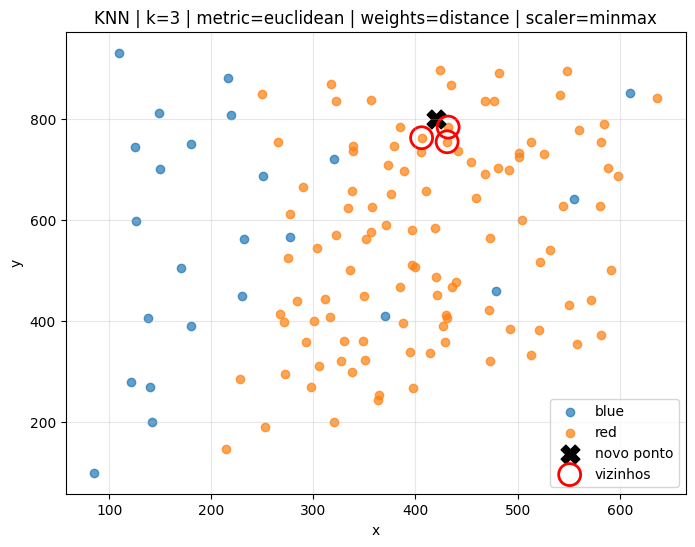

In [39]:
if len(feature_cols) == 2 and len(categorical_cols) == 0 and len(numeric_cols) == 2:
    f1, f2 = feature_cols

    plt.figure(figsize=(8, 6))

    for cls in sorted(y.unique()):
        subset = df[df[target_col] == cls]
        plt.scatter(subset[f1], subset[f2], label=str(cls), alpha=0.7)

    plt.scatter(
        new_df[f1], new_df[f2],
        c="black", marker="X", s=180, label="novo ponto"
    )

    vizinhos_plot = X_train.iloc[indices[0]]
    plt.scatter(
        vizinhos_plot[f1], vizinhos_plot[f2],
        facecolors="none", edgecolors="red", s=250, linewidths=2,
        label="vizinhos"
    )

    plt.xlabel(f1)
    plt.ylabel(f2)
    plt.title(f"KNN | k={k} | metric={metric} | weights={weights} | scaler={scaler_type}")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

In [40]:
for k_test in [1, 3, 5, 7, 9]:
    temp_model = Pipeline(steps=[
        ("prep", preprocessor),
        ("knn", KNeighborsClassifier(
            n_neighbors=k_test,
            metric=metric,
            weights=weights
        ))
    ])

    temp_model.fit(X_train, y_train)
    temp_pred = temp_model.predict(X_test)
    temp_acc = accuracy_score(y_test, temp_pred)

    print(f"k={k_test} -> acurácia={temp_acc:.4f}")

k=1 -> acurácia=0.8519
k=3 -> acurácia=0.8519
k=5 -> acurácia=0.8519
k=7 -> acurácia=0.8519
k=9 -> acurácia=0.8519
